# Data Analysis Project
### Step-by-Step Exploratory Data Analysis

## Load Data

In [ ]:
from read import fetch_api_data

fetch_api_data()

page 1 loaded!
page 2 loaded!
page 3 loaded!
page 4 loaded!
page 5 loaded!
page 6 loaded!
data fetched successfully
data saved successfully


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json
import ast

sns.set_theme(style="whitegrid")

# Load your data here
data = pd.read_csv('user.csv')

## Basic Data Exploration

### Shape of DataFrame

In [ ]:
print(f"Shape of DataFrame: {data.shape}")

Shape of DataFrame: (208, 29)


### Column Names

In [11]:
print(f"Column Names: {data.columns.tolist()}")

Column Names: ['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email', 'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress', 'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto', 'role', 'city']


### Data Types

In [16]:
print("\nData Types:")
print(data.dtypes)


Data Types:
id              int64
firstName      object
lastName       object
maidenName     object
age             int64
gender         object
email          object
phone          object
username       object
password       object
birthDate      object
image          object
bloodGroup     object
height        float64
weight        float64
eyeColor       object
hair           object
ip             object
address        object
macAddress     object
university     object
bank           object
company        object
ein            object
ssn            object
userAgent      object
crypto         object
role           object
city           object
dtype: object


### Missing Values

In [ ]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
id              0
firstName       0
lastName        0
maidenName    148
age             0
gender          0
email           0
phone           0
username        0
password        0
birthDate       0
image           0
bloodGroup      0
height          0
weight          0
eyeColor        0
hair            0
ip              0
address         0
macAddress      0
university      0
bank            0
company         0
ein             0
ssn             0
userAgent       0
crypto          0
role            0
city            0
dtype: int64


### Duplicate Rows

In [ ]:
print(f"\nDuplicate Rows: {data.duplicated().sum()}")
display(data.describe())


Duplicate Rows: 0


,id,age,height,weight
count,208.000000,208.000000,208.000000,208.000000
mean,104.500000,33.139423,175.720240,75.038606
std,60.188592,5.544269,14.119984,14.090775
min,1.000000,23.000000,150.250000,50.100000
25%,52.750000,29.000000,164.187500,62.547500
50%,104.500000,32.000000,177.430000,75.985000
75%,156.250000,36.000000,186.960000,86.992500
max,208.000000,46.000000,199.810000,99.540000


## Data Cleaning / Preparation
Extracting city from the nested 'address' column and handling missing values.

In [ ]:
def extract_city(x):
    try:
        if isinstance(x, str):
            d = ast.literal_eval(x)
            return d.get('city')
        return x.get('city')
    except:
        return None

data['city'] = data['address'].apply(extract_city)

for col in ['age', 'height', 'weight']:
    data[col] = data[col].fillna(data[col].median())

print("Cleaning Complete.")

Cleaning Complete.


## Analysis

### What is the average age of users?

In [4]:
avg_age = data['age'].mean()
print(f"Average Age: {avg_age:.2f}")

Average Age: 33.14


### Average age by gender?

C:\Users\bodyk\AppData\Local\Temp\ipykernel_24088\2358783158.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='age', data=data, estimator=np.mean, palette='viridis')


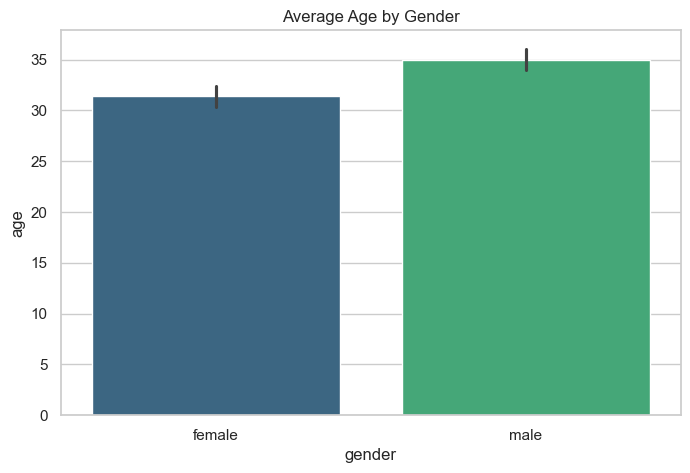

In [5]:
plt.figure(figsize=(8, 5))
sns.barplot(x='gender', y='age', data=data, estimator=np.mean, palette='viridis')
plt.title('Average Age by Gender')
plt.show()

### Number of users per gender?

C:\Users\bodyk\AppData\Local\Temp\ipykernel_24088\3288878981.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=data, palette='magma')


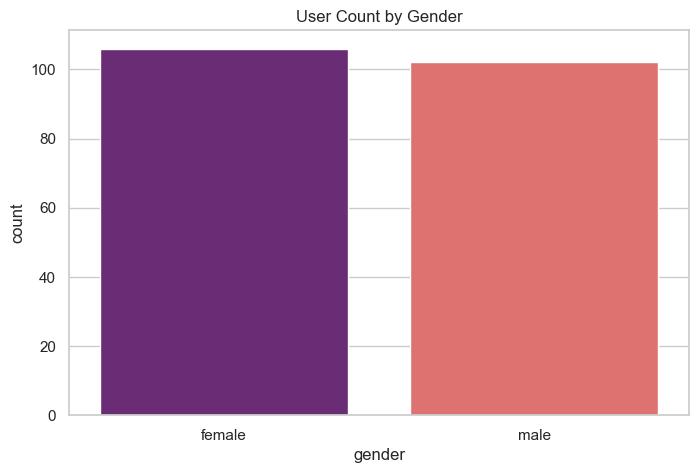

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='gender', data=data, palette='magma')
plt.title('User Count by Gender')
plt.show()

### Top 10 cities with the most users?

C:\Users\bodyk\AppData\Local\Temp\ipykernel_24088\45867714.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='rocket')


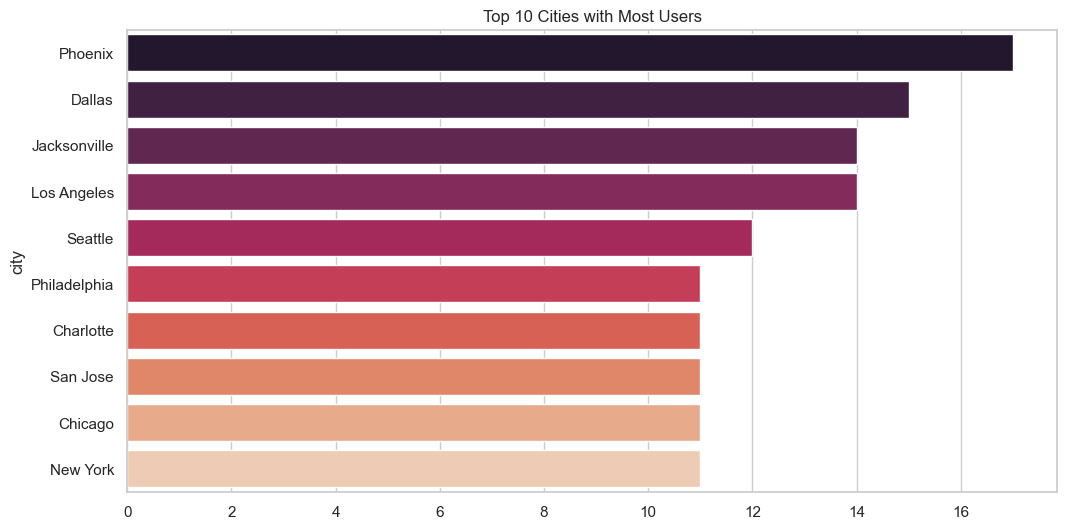

In [7]:
top_10 = data['city'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10.values, y=top_10.index, palette='rocket')
plt.title('Top 10 Cities with Most Users')
plt.show()

### Average height and weight overall?

Average Height: 175.72
Average Weight: 75.04


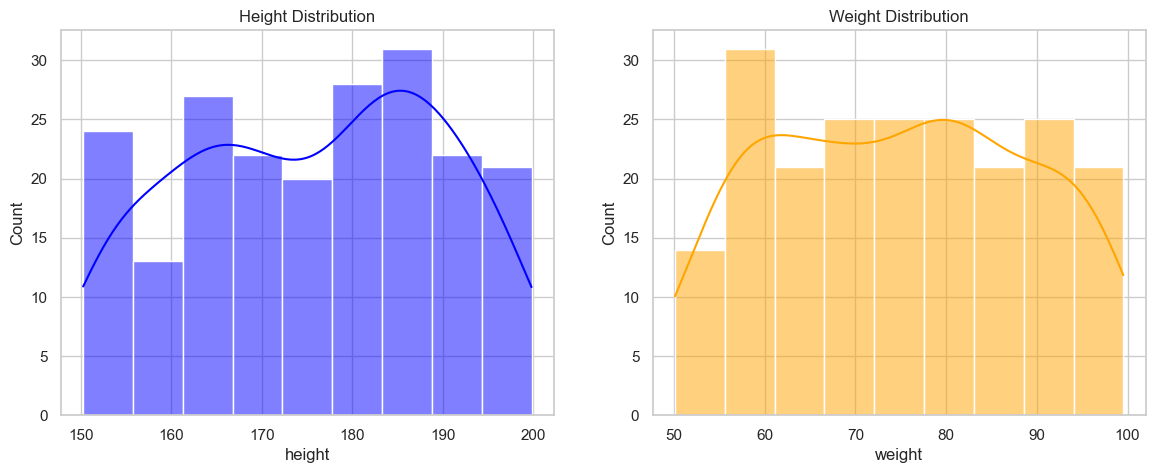

In [8]:
print(f"Average Height: {data['height'].mean():.2f}")
print(f"Average Weight: {data['weight'].mean():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data['height'], kde=True, ax=ax[0], color='blue').set_title('Height Distribution')
sns.histplot(data['weight'], kde=True, ax=ax[1], color='orange').set_title('Weight Distribution')
plt.show()

### Relationship between age and height/weight?

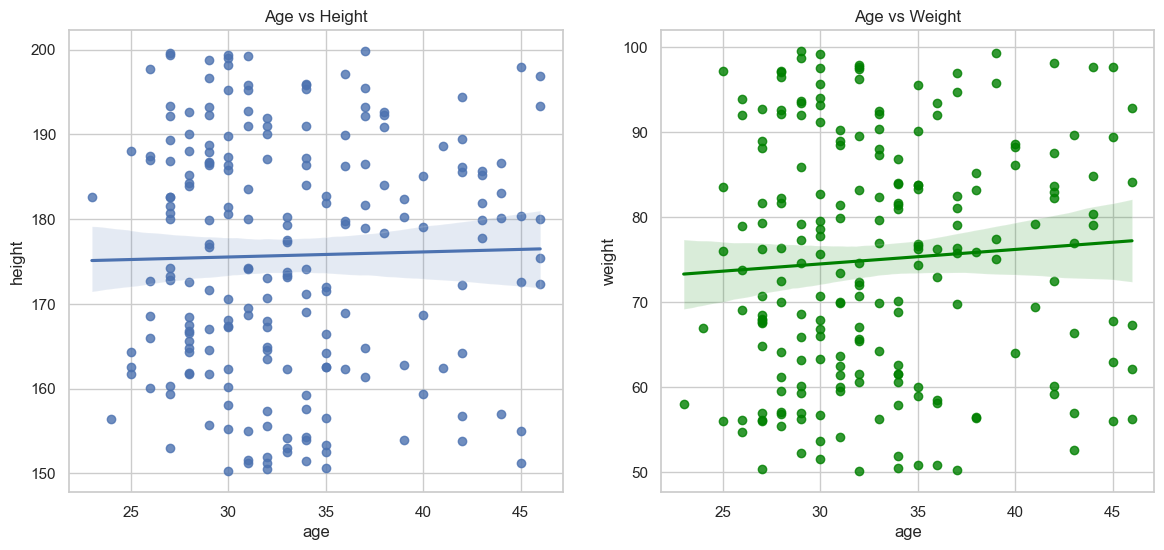

Correlation Matrix:
             age    height    weight
age     1.000000  0.023458  0.067026
height  0.023458  1.000000 -0.088655
weight  0.067026 -0.088655  1.000000


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.regplot(x='age', y='height', data=data, ax=ax[0]).set_title('Age vs Height')
sns.regplot(x='age', y='weight', data=data, ax=ax[1], color='green').set_title('Age vs Weight')
plt.show()

print("Correlation Matrix:")
print(data[['age', 'height', 'weight']].corr())